In [8]:
import os
import glob
import re

import pandas as pd
import matplotlib.pyplot as plt


def plot_and_average_csv(prefix, sub_title, xscale, total_title, xlabel, ylabel, folder="."):

    pattern = os.path.join(folder, f"{prefix}*.csv")
    files = sorted(glob.glob(pattern))

    num_pattern = re.compile(rf"^{re.escape(prefix)}(\d+)\.csv$")

    all_dfs = []

    if type(xscale) == int or type(xscale) == float:
        xscales = [xscale] * len(files)
    elif type(xscale) == list:
        xscales = xscale
    else:
        print("unrecognized xscale")
        return

    for f, scale in zip(files, xscales):
        basename = os.path.basename(f)
        m = num_pattern.search(basename)
        if not m:
            continue

        suffix = m.group(1)
        df = pd.read_csv(f, header=None)

        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")

        mask = (~x.isna()) & (~y.isna())
        x = x[mask] * scale
        y = y[mask]


        plt.figure()
        plt.plot(x, y)
        plt.title(f"{sub_title}{suffix}")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True)

        all_dfs.append(pd.DataFrame({"x": x, "y": y}))

    if not all_dfs:
        print("No found csv fill, example:", f"{prefix}1.csv, {prefix}2.csv ...")
        return

    all_data = pd.concat(all_dfs, axis=0)
    mean_df = all_data.groupby("x", as_index=False)["y"].mean()

    plt.figure()
    plt.plot(mean_df["x"], mean_df["y"])
    plt.title(total_title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    # plt.savefig(os.path.join(folder, f"{prefix}_mean.png"), dpi=300)

    mean_csv_path = os.path.join(folder, f"{prefix}_mean.csv")
    mean_df.to_csv(mean_csv_path, index=False)
    print(f"Average saved: {mean_csv_path}")

In [20]:
def plot_and_average_csv(
    prefix,
    sub_title,
    xscale,
    total_title,
    xlabel,
    ylabel,
    folder=".",
    # --- styling knobs (defaults chosen for 4-up layout) ---
    linewidth=3,
    label_fontsize=18,
    tick_fontsize=18,
    spine_width=2.5,
):
    """
    Reads {prefix}*.csv files, plots each run, computes an averaged curve over x, plots mean,
    and saves mean to {prefix}_mean.csv.

    Styling is set for compact, succinct figures: thicker lines, no grid, minimal spines,
    larger text for 4-figure-per-page layouts.
    """

    pattern = os.path.join(folder, f"{prefix}*.csv")
    files = sorted(glob.glob(pattern))

    num_pattern = re.compile(rf"^{re.escape(prefix)}(\d+)\.csv$")

    all_dfs = []

    if isinstance(xscale, (int, float)):
        xscales = [xscale] * len(files)
    elif isinstance(xscale, list):
        xscales = xscale
    else:
        print("unrecognized xscale")
        return

    def _style_axes(ax):
        """Apply supervisor-requested succinct style to a single Matplotlib Axes."""
        # No gridlines
        ax.grid(False)

        # Keep only left & bottom spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Make remaining spines slightly thicker
        ax.spines["left"].set_linewidth(spine_width)
        ax.spines["bottom"].set_linewidth(spine_width)

        # Tick styling: larger text, thicker ticks
        ax.tick_params(axis="both", which="major",
                       labelsize=tick_fontsize, width=spine_width)

        # Labels: larger relative to small figure size
        ax.xaxis.label.set_size(label_fontsize)
        ax.yaxis.label.set_size(label_fontsize)

    # -----------------------
    # Plot each individual run
    # -----------------------
    for f, scale in zip(files, xscales):
        basename = os.path.basename(f)
        m = num_pattern.search(basename)
        if not m:
            continue

        suffix = m.group(1)
        df = pd.read_csv(f, header=None)

        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")

        mask = (~x.isna()) & (~y.isna())
        x = x[mask] * scale
        y = y[mask]

        # Use fig, ax instead of global plt state (cleaner for multi-fig workflows)
        fig, ax = plt.subplots()
        ax.plot(x, y, linewidth=linewidth)

        ax.set_title(f"{sub_title}{suffix}", fontsize=label_fontsize)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        _style_axes(ax)
        fig.tight_layout()

        all_dfs.append(pd.DataFrame({"x": x, "y": y}))

    if not all_dfs:
        print("No found csv file, example:", f"{prefix}1.csv, {prefix}2.csv ...")
        return

    # -----------------------
    # Compute and plot the mean
    # -----------------------
    all_data = pd.concat(all_dfs, axis=0)
    mean_df = all_data.groupby("x", as_index=False)["y"].mean()

    fig, ax = plt.subplots()
    ax.plot(mean_df["x"], mean_df["y"], linewidth=linewidth)

    ax.set_title(total_title, fontsize=label_fontsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    _style_axes(ax)
    fig.tight_layout()

    # Save mean curve
    mean_csv_path = os.path.join(folder, f"{prefix}_mean.csv")
    mean_df.to_csv(mean_csv_path, index=False)
    print(f"Average saved: {mean_csv_path}")

In [5]:
def plot_and_average_xlsx(
    prefix,
    sub_title,
    xscale,
    total_title,
    xlabel,
    ylabel,
    folder=".",
    # --- styling knobs (defaults chosen for 4-up layout) ---
    linewidth=3,
    label_fontsize=18,
    tick_fontsize=18,
    spine_width=2.5,
):
    """
    Reads {prefix}*.xlsx files, plots each run, computes an averaged curve over x, plots mean,
    and saves mean to {prefix}_mean.csv.

    Styling is set for compact, succinct figures: thicker lines, no grid, minimal spines,
    larger text for 4-figure-per-page layouts.
    """

    pattern = os.path.join(folder, f"{prefix}*.xlsx")
    files = sorted(glob.glob(pattern))

    num_pattern = re.compile(rf"^{re.escape(prefix)}(\d+)\.xlsx$")

    all_dfs = []

    if isinstance(xscale, (int, float)):
        xscales = [xscale] * len(files)
    elif isinstance(xscale, list):
        xscales = xscale
    else:
        print("unrecognized xscale")
        return

    def _style_axes(ax):
        """Apply supervisor-requested succinct style to a single Matplotlib Axes."""
        # No gridlines
        ax.grid(False)

        # Keep only left & bottom spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Make remaining spines slightly thicker
        ax.spines["left"].set_linewidth(spine_width)
        ax.spines["bottom"].set_linewidth(spine_width)

        # Tick styling: larger text, thicker ticks
        ax.tick_params(axis="both", which="major",
                       labelsize=tick_fontsize, width=spine_width)

        # Labels: larger relative to small figure size
        ax.xaxis.label.set_size(label_fontsize)
        ax.yaxis.label.set_size(label_fontsize)

    # -----------------------
    # Plot each individual run
    # -----------------------
    for f, scale in zip(files, xscales):
        basename = os.path.basename(f)
        m = num_pattern.search(basename)
        if not m:
            continue

        suffix = m.group(1)
        df = pd.read_excel(f, header=None)

        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")

        mask = (~x.isna()) & (~y.isna())
        x = x[mask] * scale
        y = y[mask]

        # Use fig, ax instead of global plt state (cleaner for multi-fig workflows)
        fig, ax = plt.subplots()
        ax.plot(x, y, linewidth=linewidth)

        ax.set_title(f"{sub_title}{suffix}", fontsize=label_fontsize)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        _style_axes(ax)
        fig.tight_layout()

        all_dfs.append(pd.DataFrame({"x": x, "y": y}))

    if not all_dfs:
        print("No found csv file, example:", f"{prefix}1.csv, {prefix}2.csv ...")
        return

    # -----------------------
    # Compute and plot the mean
    # -----------------------
    all_data = pd.concat(all_dfs, axis=0)
    mean_df = all_data.groupby("x", as_index=False)["y"].mean()

    fig, ax = plt.subplots()
    ax.plot(mean_df["x"], mean_df["y"], linewidth=linewidth)

    ax.set_title(total_title, fontsize=label_fontsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    _style_axes(ax)
    fig.tight_layout()


In [85]:
def plot_multiple_csv(files, legends, xscale, xlabel="x", ylabel="y", title="Combined Plot", folder = "."):
    """
    files:   list of CSV file paths
    legends: list of legend names, same length as `files`
    """

    if len(files) != len(legends) or len(files) != len(xscale):
        raise ValueError("files, scales and legends must have the same length")

    plt.figure()

    for f, legend, scale in zip(files, legends, xscale):
        # read CSV (first two columns)
        pattern = os.path.join(folder, f"{f}.csv")
        df = pd.read_csv(pattern, header=None)

        # force numeric and drop invalid
        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")
        valid = (~x.isna()) & (~y.isna())
        x = x[valid] * scale
        y = y[valid]

        plt.plot(x, y, label=legend)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [52]:
def plot_two_csv_two_scales(files, xscale, label1="Y1", label2="Y2",
                            xlabel="X", title="Dual Axis Plot", folder = "."):
    pattern1 = os.path.join(folder, f"{files[0]}.csv")
    pattern2 = os.path.join(folder, f"{files[1]}.csv")
    df1 = pd.read_csv(pattern1, header=None)
    df2 = pd.read_csv(pattern2, header=None)

    x1 = pd.to_numeric(df1.iloc[:, 0], errors="coerce")
    y1 = pd.to_numeric(df1.iloc[:, 1], errors="coerce")
    x2 = pd.to_numeric(df2.iloc[:, 0], errors="coerce")
    y2 = pd.to_numeric(df2.iloc[:, 1], errors="coerce")

    fig, ax1 = plt.subplots()
    ax1.spines["top"].set_visible(False)

    # Make remaining spines slightly thicker


    ax1.plot(x1 * xscale[0], y1, label=label1, alpha=0.6, linewidth = 3)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(label1, color="blue")
    ax1.tick_params(axis="y", labelcolor="blue", labelsize=18, width=2.5)
    ax1.tick_params(axis="x", labelcolor="black", labelsize=18, width=2.5)

    ax2 = ax1.twinx()
    ax2.spines["top"].set_visible(False)

    ax2.spines["left"].set_linewidth(2.5)
    ax2.spines["bottom"].set_linewidth(2.5)
    ax2.spines["right"].set_linewidth(2.5)
    ax2.plot(x2 * xscale[1], y2, color="red", label=label2, alpha=0.6, linewidth = 3)
    ax2.set_ylabel(label2, color="red")
    ax2.tick_params(axis="y", labelcolor="red",  labelsize=18, width=2.5)
    ax1.xaxis.label.set_fontsize(18)
    ax1.yaxis.label.set_fontsize(18)
    ax2.yaxis.label.set_fontsize(18)
    ax2.xaxis.label.set_fontsize(18)

    plt.show()

In [232]:
files = ["brctmazereg_mean", "brctmazeregtrain_mean"]
legends = ["Test","Train"]
xlabel = "training episodes (for agents)"
ylabel = "R^2"
title = "Training (decoding matrix W) vs Testing R^2 for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [5, 5]

In [217]:
files = ["grutmazemi1", "grutmazemi2", "grutmazemi3"]
legends = ["1","2", "3"]
xlabel = "training episodes (for agents)"
ylabel = "Mutual information esitmation"
title = "MI estimate over different runs"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [0.5, 0.5, 0.5]

In [35]:
files = ["brctmazereg_mean", "brctmazereward"]
legends = ["R^2 of decoding","Value"]
xlabel = "training episodes (for agents)"
ylabel = "R^2/value function"
title = "R^2 and learned value function across episodes of training for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [5, 10]

In [37]:
files = ["brctmazereg_mean", "brctmazereward"]
label1 = "R^2 of decoding"
label2 = "Reward"
xlabel = "training episodes (for agents)"
ylabel = "R^2/value function"
title = "R^2 and learned reward across episodes of training for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [5, 10]

In [117]:
files = ["grutmazereg_mean", "grutmazereward"]
label1 = "R^2 of decoding"
label2 = "Reward"
xlabel = "training episodes (for agents)"
ylabel = "R^2/value function"
title = "R^2 and learned reward across episodes of training for TMaze with GRU"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [1, 10]

In [178]:
files = ["brctmazesoft1", "brctmazesoft2", "brctmazesoft3"]
legends = ["1","2", "3"]
xlabel = "training episodes (for agents)"
ylabel = "CE loss"
title = "Cross-entropy loss over different runs"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [100, 100, 100]

TypeError: 'int' object is not subscriptable

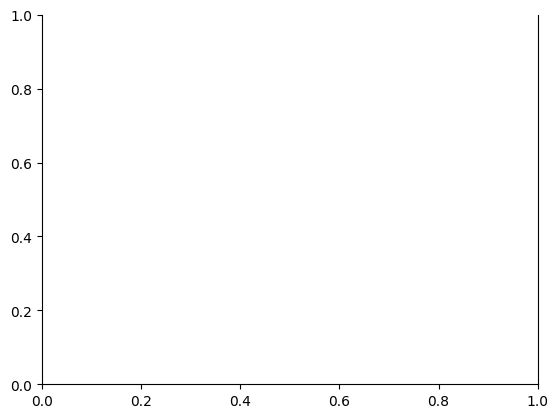

In [80]:
plot_two_csv_two_scales(files, xscale, label1, label2,
                            xlabel, title, folder)

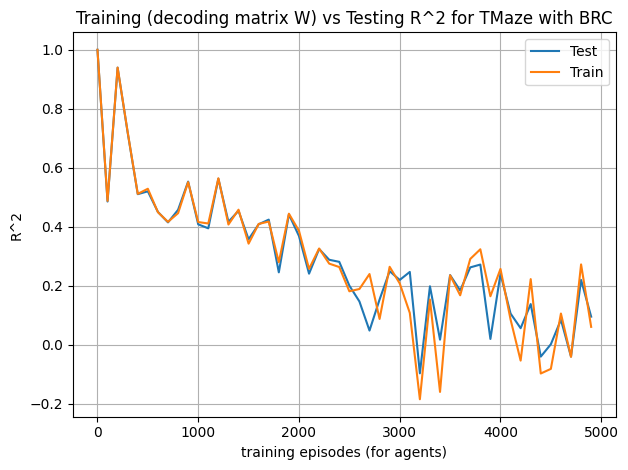

In [233]:
plot_multiple_csv(files, legends, xscale, xlabel, ylabel, title, folder)

In [19]:
prefix = "brctmazereg"
sub_title = "Test R^2 for linear decoding hidden states in TMaze with BRC"
total_title = "Average test R^2 for linear decoding hidden states in TMaze with BRC"
xlabel = "training steps"
ylabel = "R^2"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 20

In [59]:
prefix = "brctmazeregtrain"
sub_title = "Training R^2 for linear decoding hidden states in TMaze with BRC"
total_title = "Average training R^2 for linear decoding hidden states in TMaze with BRC"
xlabel = "training steps"
ylabel = "R^2"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 20

In [ ]:
prefix = "grutmazereg"
sub_title = "Test R^2 for linear decoding hidden states in TMaze with GRU"
total_title = "Average test R^2 for linear decoding hidden states in TMaze with GRU"
xlabel = "training steps"
ylabel = "R^2"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [200, 100, 100]

In [2]:
prefix = "grutmazesoft"
sub_title = "Test cross-entropy loss for classification decoding hidden states in TMaze with GRU"
total_title = "Average cross-entropy loss for classification decoding hidden states in TMaze with GRU"
xlabel = "training steps"
ylabel = "Loss"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [100, 100, 100]

In [54]:
prefix = "brctmazesoft"
sub_title = "Test cross-entropy loss for classification decoding hidden states in TMaze with BRC"
total_title = "Average cross-entropy loss for classification decoding hidden states in TMaze with BRC"
xlabel = "training steps"
ylabel = "Loss"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [100, 100, 100]

In [56]:
prefix = "brctmazemi"
sub_title = "Estimated mutual information between beliefs and hidden states in TMaze with GRU"
total_title = "Average estimated mutual information between beliefs and hidden states in TMaze with BRC"
xlabel = "training steps"
ylabel = "Mutual informaton"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [0.5, 0.5]

In [ ]:
prefix = "grustarkreg"
sub_title = "Estimated mutual information between beliefs and hidden states in TMaze with GRU"
total_title = "Average R^2 of decoding in odor test with GRU"
xlabel = "training steps"
ylabel = "R^2"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 1

In [16]:
prefix = "grustarkkl"
sub_title = "Estimated mutual information between beliefs and hidden states in TMaze with GRU"
total_title = "Average R^2 of decoding in odor test with GRU"
xlabel = "training steps"
ylabel = "KL-divergence"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 5

In [75]:
prefix = "grustark0.8on0.8"
sub_title = "Estimated mutual information between beliefs and hidden states in TMaze with GRU"
total_title = "Average R^2 of decoding in odor test with GRU"
xlabel = "training steps"
ylabel = "MI"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 5

In [24]:
prefix = "kl2_vs_episodes"
total_title = "Average R^2 of decoding in odor test with GRU"
xlabel = "training steps"
ylabel = "KL-divergence"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 1

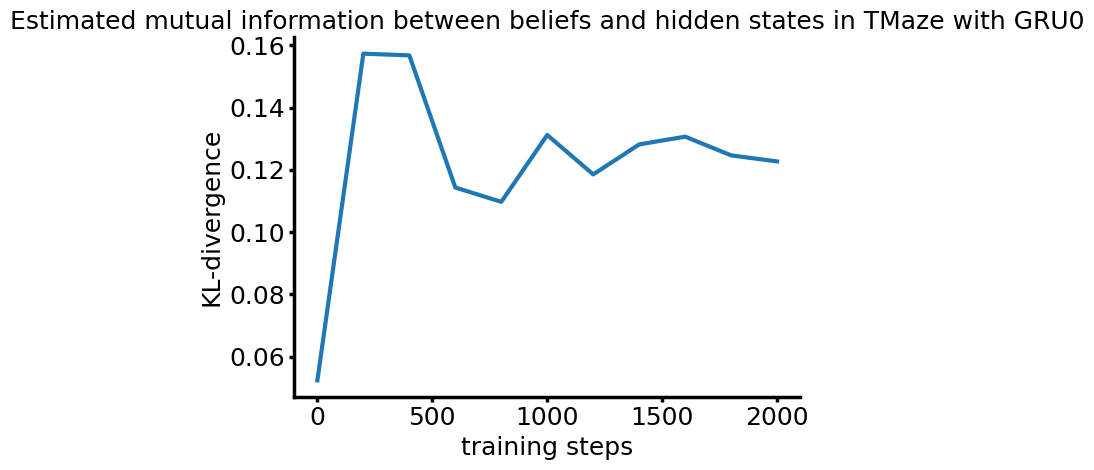

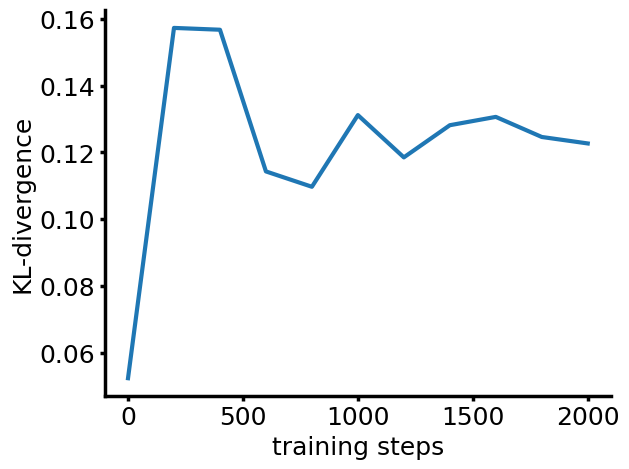

In [25]:
plot_and_average_xlsx(prefix, sub_title, xscale, None, xlabel, ylabel, folder)

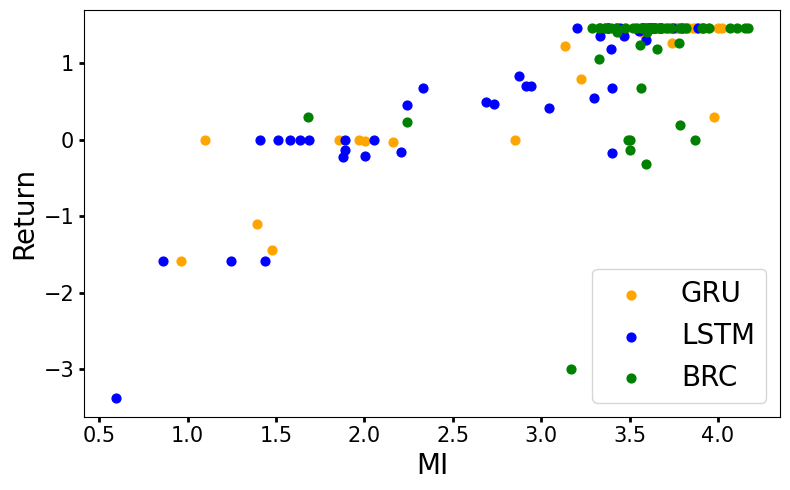

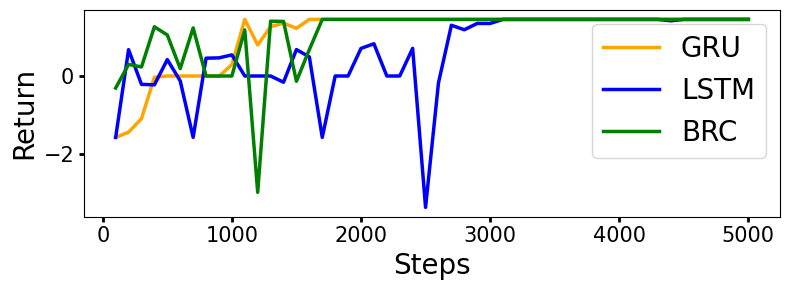

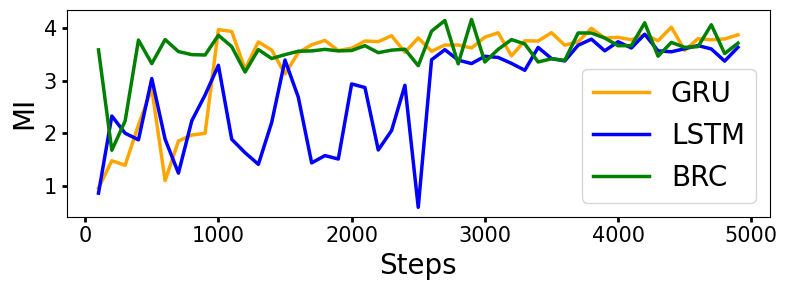

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(r"D:\Life\University\项目\Mate\gru-multiple run\panels.xlsx") 

# -------------------------------
# Panel 1: Scatter (reward vs MI)
# -------------------------------
plt.figure(figsize=(8, 5))

# GRU
gru = df[['GRU', 'MI']].dropna()
plt.scatter(gru['MI'], gru['GRU'], color='orange', label='GRU', s=40)

# LSTM
lstm = df[['LSTM', 'MI.1']].dropna()
plt.scatter(lstm['MI.1'], lstm['LSTM'], color='blue', label='LSTM', s=40)

# BRC
brc = df[['BRC', 'MI.2']].dropna()
plt.scatter(brc['MI.2'], brc['BRC'], color='green', label='BRC', s=40)

plt.ylabel("Return", fontsize=20)
plt.xlabel("MI", fontsize=20)
plt.legend(fontsize=20)
plt.tick_params(axis="both", which="major",
                       labelsize=15, width=2)

plt.tight_layout()
plt.show()


# -------------------------------
# Panel 2: Reward vs Steps
# -------------------------------
plt.figure(figsize=(8, 3))
steps = df['Step'] * 10
plt.plot(steps, df['GRU'], color='orange', linewidth = 2.5, label='GRU')
plt.plot(steps, df['LSTM'], color='blue', linewidth = 2.5,  label='LSTM')
plt.plot(steps, df['BRC'], color='green', linewidth = 2.5, label='BRC')
plt.tick_params(axis="both", which="major",
                       labelsize=15, width=2)

plt.xlabel("Steps", fontsize=20)
plt.ylabel("Return", fontsize=20)

plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


# -------------------------------
# Panel 3: MI vs Steps
# -------------------------------
plt.figure(figsize=(8, 3))
plt.plot(steps, df['MI'], color='orange', linewidth = 2.5, label='GRU')
plt.plot(steps, df['MI.1'], color='blue', linewidth = 2.5, label='LSTM')
plt.plot(steps, df['MI.2'], color='green', linewidth = 2.5, label='BRC')

plt.xlabel("Steps", fontsize=20)
plt.ylabel("MI", fontsize=20)
plt.tick_params(axis="both", which="major",
                       labelsize=15, width=2)

plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


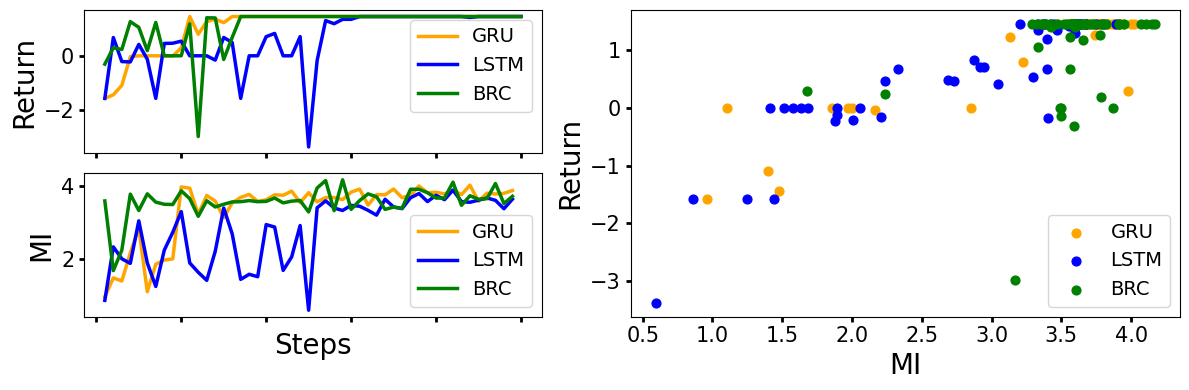

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

df = pd.read_excel(r"D:\Life\University\项目\Mate\gru-multiple run\panels.xlsx")

steps = df['Step'] * 10

# Create figure and grid
fig = plt.figure(figsize=(12, 4))
gs = GridSpec(2, 2, width_ratios=[1.0, 1.2], height_ratios=[1, 1], figure=fig)

# ===============================
# Panel 2: Reward vs Steps (top-left)
# ===============================
ax2 = fig.add_subplot(gs[0, 0])
ax2.plot(steps, df['GRU'], color='orange', linewidth=2.5, label='GRU')
ax2.plot(steps, df['LSTM'], color='blue', linewidth=2.5, label='LSTM')
ax2.plot(steps, df['BRC'], color='green', linewidth=2.5, label='BRC')

ax2.set_ylabel("Return", fontsize=20)
ax2.tick_params(axis="both", which="major", labelsize=15, width=2)
ax2.legend(fontsize=14)
ax2.set_xticklabels([])  # hide x labels for stacked plot

# ===============================
# Panel 3: MI vs Steps (bottom-left)
# ===============================
ax3 = fig.add_subplot(gs[1, 0], sharex=ax2)
ax3.plot(steps, df['MI'], color='orange', linewidth=2.5, label='GRU')
ax3.plot(steps, df['MI.1'], color='blue', linewidth=2.5, label='LSTM')
ax3.plot(steps, df['MI.2'], color='green', linewidth=2.5, label='BRC')

ax3.set_xlabel("Steps", fontsize=20)
ax3.set_ylabel("MI", fontsize=20)
ax3.tick_params(axis="both", which="major", labelsize=15, width=2)
ax3.legend(fontsize=14)

# ===============================
# Panel 1: Scatter (right, spanning rows)
# ===============================
ax1 = fig.add_subplot(gs[:, 1])

gru = df[['GRU', 'MI']].dropna()
ax1.scatter(gru['MI'], gru['GRU'], color='orange', s=40, label='GRU')

lstm = df[['LSTM', 'MI.1']].dropna()
ax1.scatter(lstm['MI.1'], lstm['LSTM'], color='blue', s=40, label='LSTM')

brc = df[['BRC', 'MI.2']].dropna()
ax1.scatter(brc['MI.2'], brc['BRC'], color='green', s=40, label='BRC')

ax1.set_xlabel("MI", fontsize=20)
ax1.set_ylabel("Return", fontsize=20)
ax1.tick_params(axis="both", which="major", labelsize=15, width=2)
ax1.legend(fontsize=14)

plt.tight_layout()
plt.show()
